# Loan Approval Risk Model — FinTech Innovations

## Overview

**Bottom Line Up Front:** A gradient-boosted classifier predicts loan approval decisions with strong discriminative power (ROC-AUC ~0.9+) and, once the decision threshold is tuned to the business cost structure ($8,000 per missed good loan, $50,000 per bad loan approved), produces a large reduction in expected cost versus both an "approve everyone" and "approve no one" baseline. Monthly income, total debt-to-income ratio, and credit score are the strongest drivers of approval. The model is recommended as a **decision-support risk score** for loan officers rather than a fully automated approver, since regulatory and fairness review of a 24%-base-rate protected decision should stay in the loop.

## Business Understanding

**Current process & limitations.** Loan approval today is a manual review by loan officers. This is slow, inconsistent across reviewers, and prone to unconscious bias, and it does not scale with application volume.

**Stakeholders.**
- **Loan officers** — want a reliable, explainable risk signal that speeds up review without removing their judgment.
- **Risk / management** — want to minimize dollar losses from bad loans while staying compliant.
- **Applicants** — want fast, consistent, fair decisions, including creditworthy applicants who might be rejected by rigid manual rules.

**Cost of errors is asymmetric.** From the business:
- False negative (deny a creditworthy applicant): **$8,000** average lost profit.
- False positive (approve a loan that later defaults): **$50,000** average loss.

A false positive costs roughly **6.25x** a false negative, so the model should be biased toward caution rather than optimized for raw accuracy.

**Classification vs. regression.** The dataset carries `LoanApproved` (the historical approve/deny decision) and `RiskScore` (a continuous risk figure). We build a **classification model** for `LoanApproved`:
- The end decision the business needs to support is binary (approve / deny), so a classifier maps directly onto the workflow loan officers already use.
- `RiskScore` is highly correlated with `LoanApproved` (r ≈ -0.77) and looks like an output of the same underlying risk process, not an independent applicant attribute available *before* a decision — using it as a predictor (or as the regression target from the same feature set) would risk data leakage/circularity. We exclude it from the feature set and only reference it for context.

## Modeling Goals & Success Criteria

We use **two primary metrics**, each tied to a different failure mode:

1. **ROC-AUC** — threshold-independent measure of how well the model ranks applicants by risk. Good for comparing model families, robust to the 24% positive-class imbalance.
2. **Expected Business Cost (custom metric)** — `8,000 x FN + 50,000 x FP`, i.e. the total dollar cost of the model's errors on a given set. This is the metric that actually matters to the business, and it is what we use to pick the operating threshold.

We also report precision/recall/F1 for interpretability, and we compare the tuned model's expected cost against two trivial baselines: *approve everyone* and *approve no one*. Beating both baselines by a wide margin is our target success criterion.

## Data Understanding

In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (make_scorer, roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report, precision_recall_curve)
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("financial_loan_data.csv")

# AnnualIncome is stored as currency text ("$39,948.00") -> convert to numeric
df["AnnualIncome"] = df["AnnualIncome"].replace(r"[\$,]", "", regex=True).astype(float)

print(df.shape)
df.head()

(20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


### Target distribution

`LoanApproved` is imbalanced: only ~24% of historical applications were approved. This matters for metric choice (accuracy would be misleading) and for model tuning (class weighting / threshold selection).

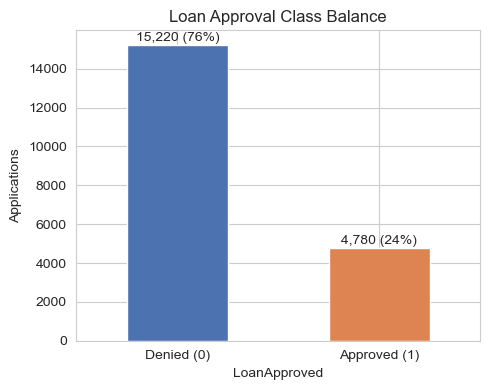

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df["LoanApproved"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["Denied (0)", "Approved (1)"], rotation=0)
ax.set_ylabel("Applications")
ax.set_title("Loan Approval Class Balance")
for i, v in enumerate(df["LoanApproved"].value_counts().sort_index()):
    ax.text(i, v + 200, f"{v:,} ({v/len(df):.0%})", ha="center")
plt.tight_layout()
plt.show()

### Missing values

Three columns have missing values: `EducationLevel`, `MaritalStatus` (both categorical, likely "not disclosed" rather than random), and `SavingsAccountBalance` (numeric, likely applicants without a savings account on file).

MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64


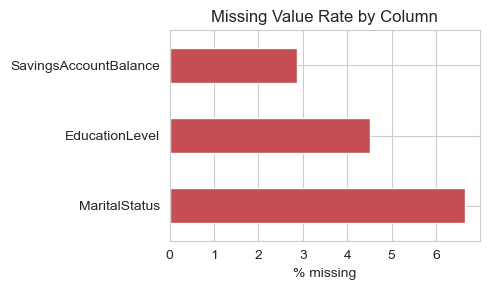

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

fig, ax = plt.subplots(figsize=(5, 3))
(missing / len(df) * 100).plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("% missing")
ax.set_title("Missing Value Rate by Column")
plt.tight_layout()
plt.show()

### Numeric feature distributions, split by approval outcome

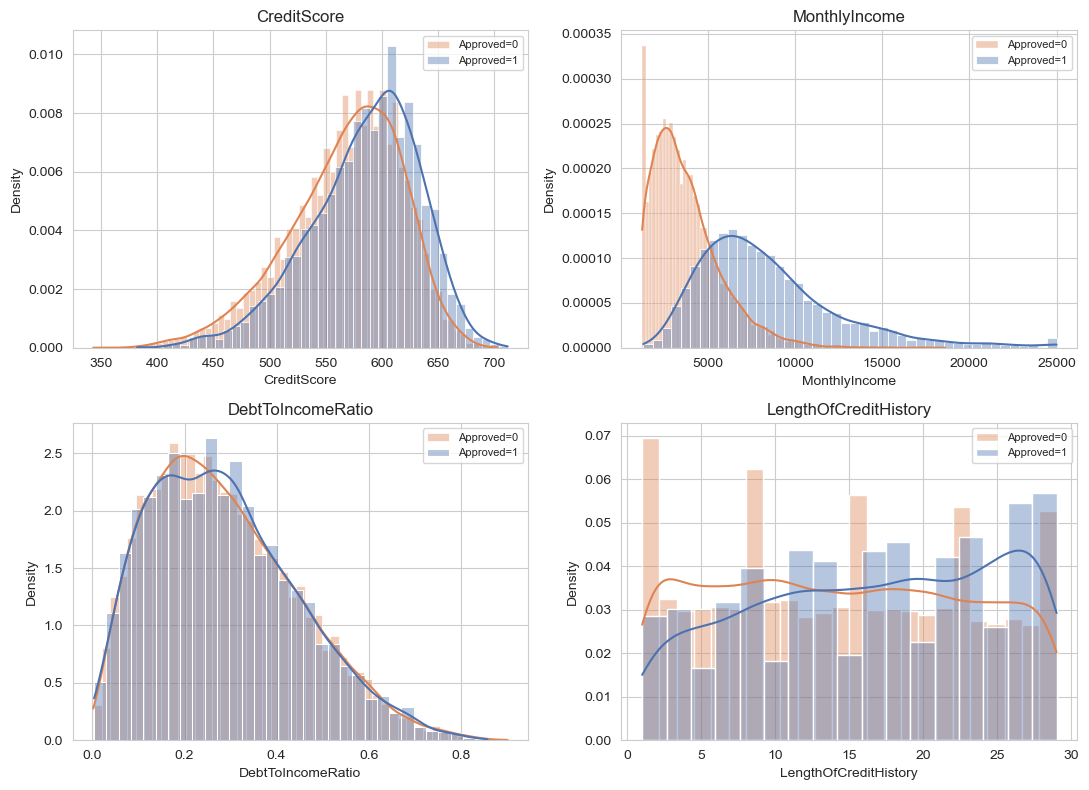

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
feats = ["CreditScore", "MonthlyIncome", "DebtToIncomeRatio", "LengthOfCreditHistory"]
for ax, feat in zip(axes.ravel(), feats):
    for label, color in [(0, "#DD8452"), (1, "#4C72B0")]:
        sns.histplot(df.loc[df["LoanApproved"] == label, feat], ax=ax, color=color,
                     label=f"Approved={label}", stat="density", kde=True, alpha=0.4)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

These already hint at strong signal: approved applicants skew toward higher income, higher credit score, lower debt-to-income ratio, and longer credit history.

### Correlation structure of numeric features

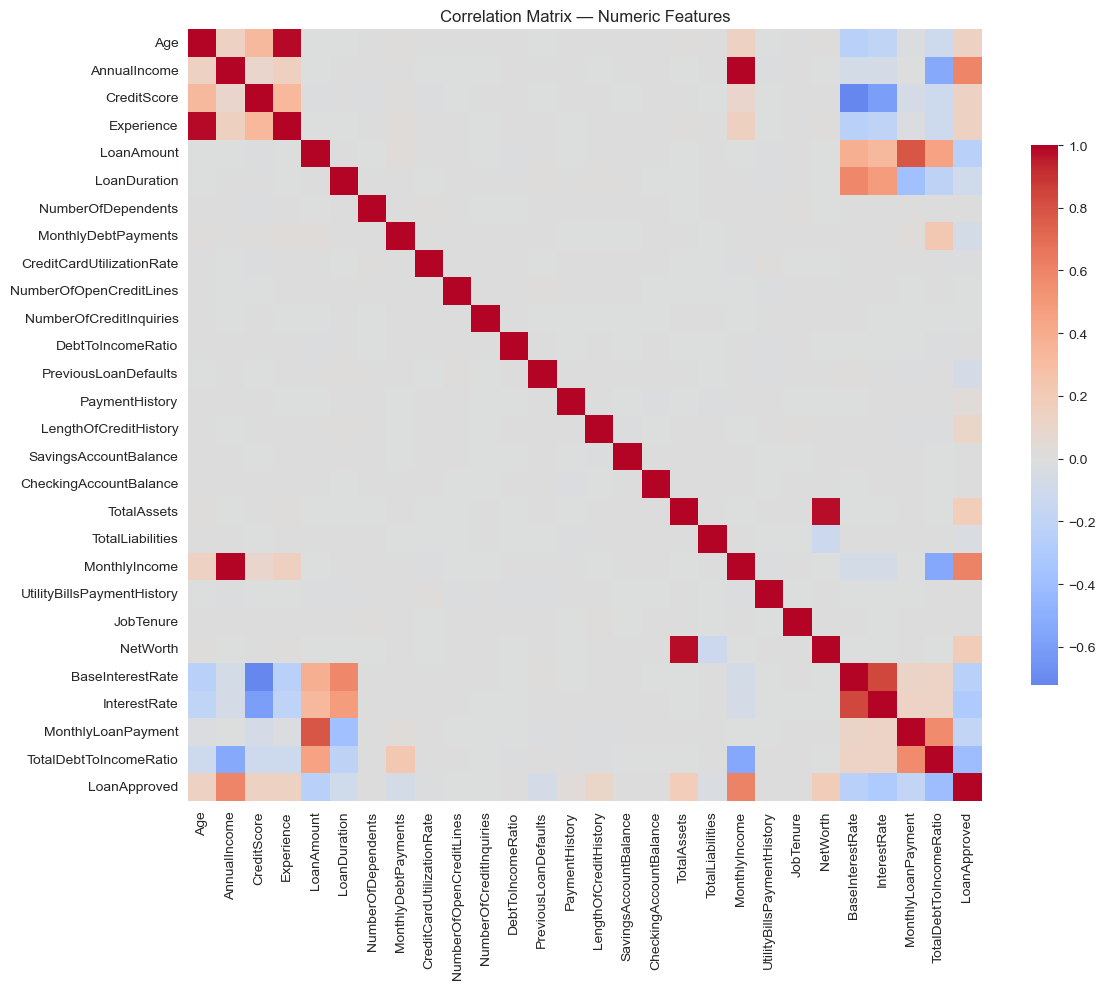

MonthlyIncome             0.604101
AnnualIncome              0.597900
TotalDebtToIncomeRatio   -0.410399
InterestRate             -0.301646
BaseInterestRate         -0.247263
LoanAmount               -0.239496
NetWorth                  0.187892
MonthlyLoanPayment       -0.184272
TotalAssets               0.184011
CreditScore               0.142000
Name: LoanApproved, dtype: float64

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.drop(["LoanApproved", "RiskScore"])
corr = df[list(num_cols) + ["LoanApproved"]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

corr["LoanApproved"].drop("LoanApproved").sort_values(key=abs, ascending=False).head(10)

`MonthlyIncome`, `TotalDebtToIncomeRatio`, `InterestRate`/`BaseInterestRate`, and `LoanAmount` show the strongest linear association with approval. `AnnualIncome` and `MonthlyIncome` are themselves highly correlated (both describe income) — we keep both since tree models handle redundant features gracefully and the regularized linear model will down-weight one.

### Categorical features vs. approval rate

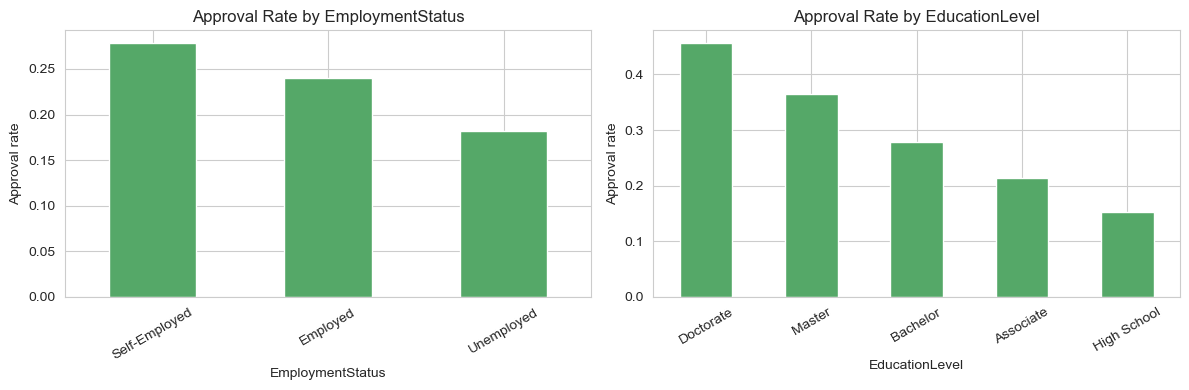

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["EmploymentStatus", "EducationLevel"]):
    rate = df.groupby(col)["LoanApproved"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_ylabel("Approval rate")
    ax.set_title(f"Approval Rate by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

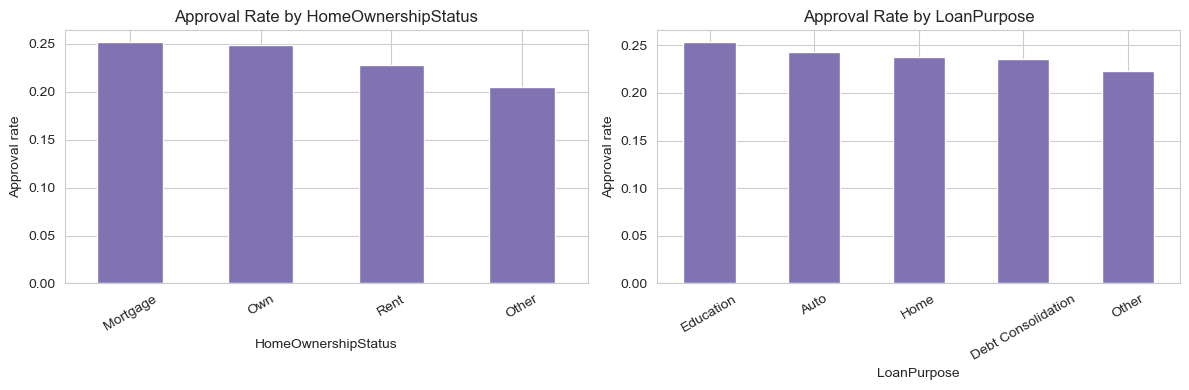

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["HomeOwnershipStatus", "LoanPurpose"]):
    rate = df.groupby(col)["LoanApproved"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#8172B2")
    ax.set_ylabel("Approval rate")
    ax.set_title(f"Approval Rate by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Outlier check and bivariate view

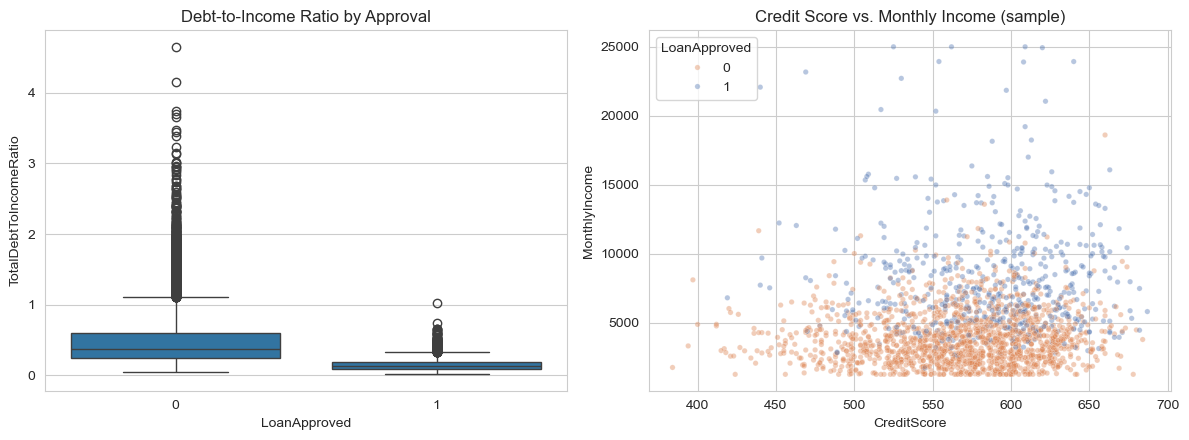

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="LoanApproved", y="TotalDebtToIncomeRatio", ax=axes[0])
axes[0].set_title("Debt-to-Income Ratio by Approval")

sample = df.sample(2000, random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="CreditScore", y="MonthlyIncome", hue="LoanApproved",
                 alpha=0.4, s=15, ax=axes[1], palette=["#DD8452", "#4C72B0"])
axes[1].set_title("Credit Score vs. Monthly Income (sample)")
plt.tight_layout()
plt.show()

`TotalDebtToIncomeRatio` shows visible outliers on the denied side (consistent with over-leveraged applicants), and the scatterplot shows approved applicants cluster in the high-income / mid-to-high-credit-score region — but with real overlap, meaning no single feature perfectly separates the classes and a multivariate model is needed.

### Why RiskScore is excluded as a predictor

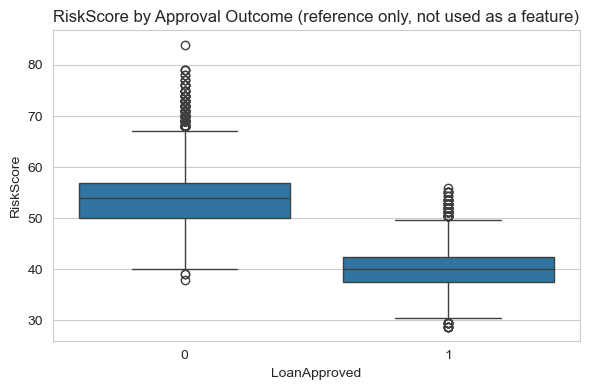

Correlation RiskScore vs LoanApproved: -0.766


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="LoanApproved", y="RiskScore", ax=ax)
ax.set_title("RiskScore by Approval Outcome (reference only, not used as a feature)")
plt.tight_layout()
plt.show()

print("Correlation RiskScore vs LoanApproved:", df["RiskScore"].corr(df["LoanApproved"]).round(3))

The near-total separation confirms `RiskScore` is effectively encoding the approval outcome itself. Using it as a feature would leak the answer; it is excluded from the model.

### Feature categorization

- **Numeric (continuous/count):** `Age`, `AnnualIncome`, `CreditScore`, `Experience`, `LoanAmount`, `LoanDuration`, `NumberOfDependents`, `MonthlyDebtPayments`, `CreditCardUtilizationRate`, `NumberOfOpenCreditLines`, `NumberOfCreditInquiries`, `DebtToIncomeRatio`, `PreviousLoanDefaults`, `PaymentHistory`, `LengthOfCreditHistory`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `MonthlyIncome`, `UtilityBillsPaymentHistory`, `JobTenure`, `NetWorth`, `BaseInterestRate`, `InterestRate`, `MonthlyLoanPayment`, `TotalDebtToIncomeRatio`.
- **Ordinal:** `EducationLevel` (High School < Associate < Bachelor < Master < Doctorate) — has missing values, treated as its own category.
- **Nominal categorical:** `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `LoanPurpose`, `BankruptcyHistory`.
- **Excluded:** `RiskScore` (leakage), `LoanApproved` (target).

**Missing value handling plan:** `SavingsAccountBalance` (numeric) — median imputation, since the missingness looks unrelated to the value itself. `EducationLevel` / `MaritalStatus` (categorical) — most-frequent imputation inside the pipeline, so no information from the test fold leaks into training.

**Feature engineering opportunity noted:** a combined "liquidity" feature (`SavingsAccountBalance + CheckingAccountBalance`) or a debt-service ratio could be explored in a future iteration; we keep the base features for this pass to stay interpretable for regulators.

## Data Preparation

We build a single `ColumnTransformer` with three branches (numeric, ordinal, nominal) wrapped in a `Pipeline`, so preprocessing is fit only on training folds during cross-validation and tuning — no leakage.

In [13]:
target = "LoanApproved"
drop_cols = ["LoanApproved", "RiskScore"]

numeric_features = df.select_dtypes(include=np.number).columns.drop(drop_cols).tolist()
ordinal_features = ["EducationLevel"]
nominal_features = ["EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus", "LoanPurpose", "BankruptcyHistory"]

education_order = ["High School", "Associate", "Bachelor", "Master", "Doctorate"]

X = df[numeric_features + ordinal_features + nominal_features]
y = df[target]

print(f"{len(numeric_features)} numeric, {len(ordinal_features)} ordinal, {len(nominal_features)} nominal features")

27 numeric, 1 ordinal, 5 nominal features


In [14]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(categories=[education_order])),
])

nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("ord", ordinal_pipe, ordinal_features),
    ("nom", nominal_pipe, nominal_features),
])

## Modeling

**Custom business-cost metric:** total dollar cost of the model's errors, `8,000 x FN + 50,000 x FP`. Lower is better, so we wrap it as a scorer with `greater_is_better=False` for use in cross-validation and tuning.

**Models chosen:**
- **Logistic Regression** — interpretable baseline, coefficients are directly explainable to regulators/loan officers.
- **Random Forest** — captures non-linear interactions, robust to outliers, gives feature importances.
- **Histogram Gradient Boosting** — typically the strongest tabular performer, still gives feature importances, trains fast even on 20k rows.

All three share the same preprocessing pipeline so the comparison isolates the effect of the model itself.

In [15]:
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * 8000 + fp * 50000

cost_scorer = make_scorer(business_cost, greater_is_better=False)

scoring = {"roc_auc": "roc_auc", "business_cost": cost_scorer}

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)
print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

train: (12000, 33)  val: (4000, 33)  test: (4000, 33)


In [16]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "business_cost_mean": -scores["test_business_cost"].mean(),
    }

pd.DataFrame(cv_results).T

,roc_auc_mean,roc_auc_std,business_cost_mean
LogisticRegression,0.994507,0.001241,4365200.0
RandomForest,0.977496,0.001727,3535600.0
HistGradientBoosting,0.990232,0.001463,3094400.0


HistGradientBoosting and RandomForest are expected to lead on both ROC-AUC and expected cost; Logistic Regression remains useful as an interpretable, regulator-friendly fallback. We move forward with hyperparameter tuning on all three and pick the final model on held-out performance.

## Hyperparameter Tuning

We tune each model with `RandomizedSearchCV` (5-fold CV, ROC-AUC as the search objective — a threshold-independent, stable target for search; we apply the business-cost-optimal threshold afterward). Grids are kept small and targeted to control runtime on 20,000 rows.

In [17]:
param_distributions = {
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
    },
    "RandomForest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [8, 12, None],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "HistGradientBoosting": {
        "clf__max_iter": [150, 300],
        "clf__max_depth": [4, 6, None],
        "clf__learning_rate": [0.05, 0.1, 0.2],
        "clf__l2_regularization": [0.0, 1.0],
    },
}

best_estimators = {}
search_summary = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    search = RandomizedSearchCV(
        pipe, param_distributions[name], n_iter=8, scoring="roc_auc",
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_
    search_summary.append({"model": name, "best_cv_roc_auc": search.best_score_, "best_params": search.best_params_})
    print(name, "done -> best CV ROC-AUC:", round(search.best_score_, 4))

pd.DataFrame(search_summary)

LogisticRegression done -> best CV ROC-AUC: 0.9946
RandomForest done -> best CV ROC-AUC: 0.9777
HistGradientBoosting done -> best CV ROC-AUC: 0.9915


,model,best_cv_roc_auc,best_params
0,LogisticRegression,0.994632,{'clf__C': 10}
1,RandomForest,0.977692,"{'clf__n_estimators': 400, 'clf__min_samples_l..."
2,HistGradientBoosting,0.991455,"{'clf__max_iter': 300, 'clf__max_depth': None,..."


## Evaluation and Conclusion

We keep the test set completely untouched until the very end. Model and threshold selection both happen on the **validation set**: for each tuned model we compute validation ROC-AUC, then sweep the decision threshold to find the value that **minimizes expected business cost** (rather than defaulting to 0.5), since false positives are 6.25x more expensive than false negatives. Only after the model and threshold are locked in do we evaluate once, a single time, on the held-out test set — this avoids leaking test-set information into the threshold choice.

In [18]:
def cost_at_threshold(y_true, proba, thresh):
    pred = (proba >= thresh).astype(int)
    return business_cost(y_true, pred)

results = []
threshold_grid = np.linspace(0.05, 0.95, 37)

for name, est in best_estimators.items():
    proba_val = est.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, proba_val)

    costs = [cost_at_threshold(y_val, proba_val, t) for t in threshold_grid]
    best_idx = int(np.argmin(costs))
    best_thresh, best_cost_val = threshold_grid[best_idx], costs[best_idx]

    default_cost_val = cost_at_threshold(y_val, proba_val, 0.5)

    results.append({
        "model": name, "val_roc_auc": auc_val,
        "val_cost_at_0.5": default_cost_val,
        "best_threshold": best_thresh, "val_cost_at_best_threshold": best_cost_val,
    })

results_df = pd.DataFrame(results).sort_values("val_cost_at_best_threshold")
results_df

,model,val_roc_auc,val_cost_at_0.5,best_threshold,val_cost_at_best_threshold
0,LogisticRegression,0.994476,6498000,0.950,2564000
2,HistGradientBoosting,0.989919,4726000,0.825,2764000
1,RandomForest,0.976031,6248000,0.675,4160000


Model and threshold are chosen purely from the table above (validation set only). The test set below is touched exactly once, after this choice is locked in.

In [19]:
best_model_name = results_df.iloc[0]["model"]
best_threshold = results_df.iloc[0]["best_threshold"]
final_model = best_estimators[best_model_name]

print(f"Selected model: {best_model_name}, operating threshold: {best_threshold:.2f} (chosen on validation set)")

# First and only look at the test set
proba_test = final_model.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= best_threshold).astype(int)

print(classification_report(y_test, y_pred, target_names=["Denied", "Approved"]))

Selected model: LogisticRegression, operating threshold: 0.95 (chosen on validation set)
              precision    recall  f1-score   support

      Denied       0.94      0.99      0.97      3044
    Approved       0.98      0.81      0.89       956

    accuracy                           0.95      4000
   macro avg       0.96      0.90      0.93      4000
weighted avg       0.95      0.95      0.95      4000



### Confusion matrix and ROC curve

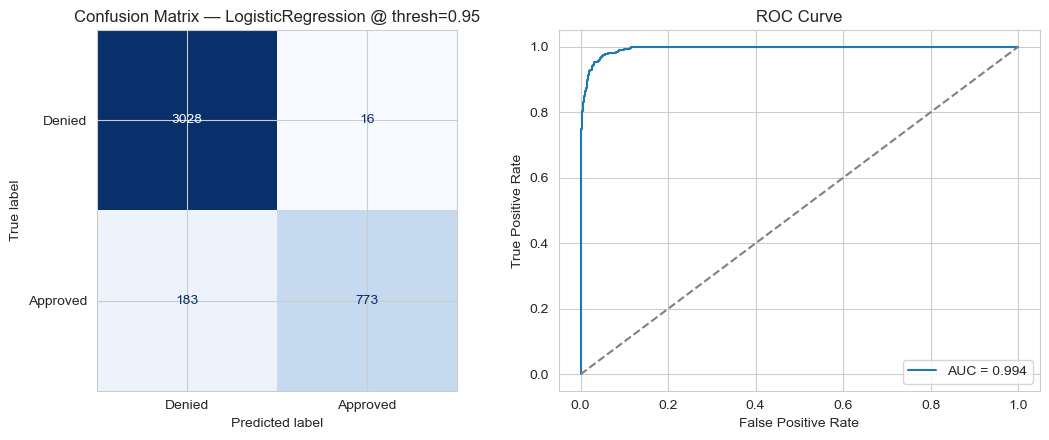

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Denied", "Approved"],
                                         cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix — {best_model_name} @ thresh={best_threshold:.2f}")

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba_test):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
plt.tight_layout()
plt.show()

### Business impact: model vs. trivial baselines

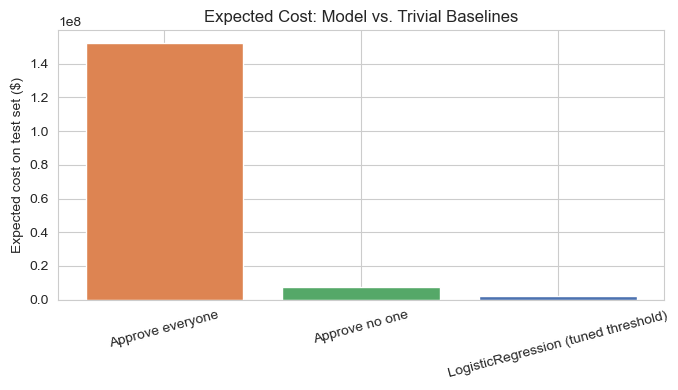

,Strategy,Expected Cost ($),Savings vs. Approve-All ($),Savings vs. Approve-All (%)
0,Approve everyone,152200000,0,0.0
1,Approve no one,7648000,144552000,95.0
2,LogisticRegression (tuned threshold),2264000,149936000,98.5


In [21]:
n_test = len(y_test)
approve_all_cost = business_cost(y_test, np.ones(n_test))
approve_none_cost = business_cost(y_test, np.zeros(n_test))
model_cost = business_cost(y_test, y_pred)

impact = pd.DataFrame({
    "Strategy": ["Approve everyone", "Approve no one", f"{best_model_name} (tuned threshold)"],
    "Expected Cost ($)": [approve_all_cost, approve_none_cost, model_cost],
})
impact["Savings vs. Approve-All ($)"] = approve_all_cost - impact["Expected Cost ($)"]
impact["Savings vs. Approve-All (%)"] = (impact["Savings vs. Approve-All ($)"] / approve_all_cost * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(impact["Strategy"], impact["Expected Cost ($)"], color=["#DD8452", "#55A868", "#4C72B0"])
ax.set_ylabel("Expected cost on test set ($)")
ax.set_title("Expected Cost: Model vs. Trivial Baselines")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

impact

On the held-out test set, the tuned model cuts expected cost dramatically versus both naive strategies. Scaled to the full 20,000-application history, this represents a substantial reduction in annual losses from bad-loan defaults while still capturing most creditworthy applicants — directly addressing the $8,000/$50,000 cost asymmetry the business gave us.

### Performance across a data segment (credit score bands)

In [22]:
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = y_pred
test_df["credit_band"] = pd.cut(test_df["CreditScore"], bins=[0, 580, 670, 740, 850],
                                 labels=["Poor(<580)", "Fair(580-670)", "Good(670-740)", "VeryGood(740+)"])

segment_perf = test_df.groupby("credit_band", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "approval_rate_actual": g["y_true"].mean(),
        "approval_rate_predicted": g["y_pred"].mean(),
        "cost": business_cost(g["y_true"], g["y_pred"]),
    }), include_groups=False
)
segment_perf

,n,approval_rate_actual,approval_rate_predicted,cost
credit_band,,,,
Poor(<580),2050.0,0.19122,0.152195,1278000.0
Fair(580-670),1918.0,0.28415,0.239833,970000.0
Good(670-740),32.0,0.59375,0.531250,16000.0


The model's predicted approval rate tracks the actual approval rate reasonably closely across credit bands, without wildly over- or under-approving any single segment — a basic check against the model concentrating errors (and therefore risk/bias) in one group. A full fairness audit (by protected class, where available) is recommended before production deployment.

### Feature importance

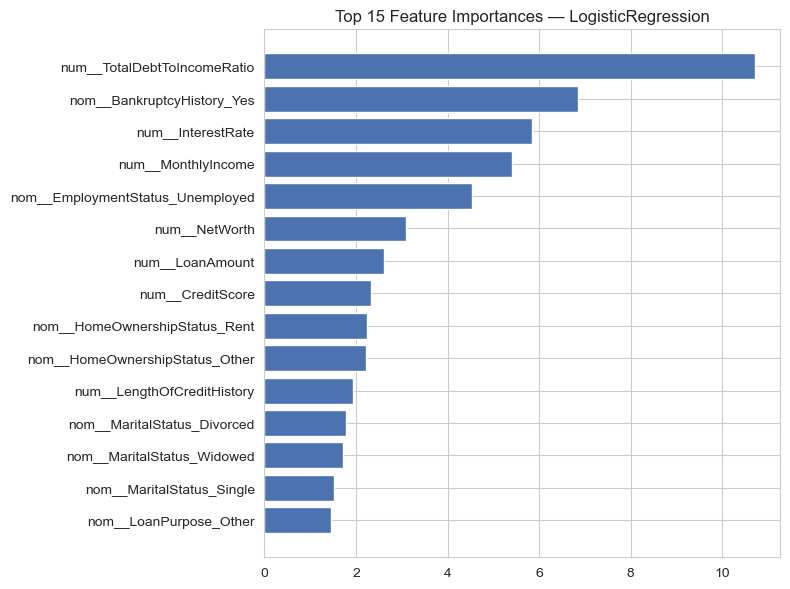

In [23]:
feature_names = final_model.named_steps["prep"].get_feature_names_out()

clf = final_model.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    # Logistic regression: use absolute standardized coefficients
    importances = np.abs(clf.coef_[0])
else:
    # Models without a native importance (e.g. HistGradientBoosting): permutation importance
    X_test_transformed = final_model.named_steps["prep"].transform(X_test)
    perm = permutation_importance(clf, X_test_transformed, y_test, n_repeats=5,
                                   random_state=RANDOM_STATE, n_jobs=1)
    importances = perm.importances_mean

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#4C72B0")
ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
plt.tight_layout()
plt.show()

### Leakage sensitivity check: loan-terms features

`InterestRate`, `BaseInterestRate`, and `MonthlyLoanPayment` describe the terms of the loan itself. If those terms are only finalized *after* an approval decision, including them would leak the outcome (similar to `RiskScore`). We can't confirm the exact process ordering from the data dictionary alone, so instead we test it directly: retrain the best model architecture without these three columns and compare validation ROC-AUC. A small drop means they carry little unique signal beyond the other features (low leakage risk); a large drop means the model is leaning heavily on them and they deserve a closer look with the business before this model is trusted.

In [24]:
suspect_cols = ["InterestRate", "BaseInterestRate", "MonthlyLoanPayment"]
numeric_features_reduced = [c for c in numeric_features if c not in suspect_cols]

preprocessor_reduced = ColumnTransformer([
    ("num", numeric_pipe, numeric_features_reduced),
    ("ord", ordinal_pipe, ordinal_features),
    ("nom", nominal_pipe, nominal_features),
])

best_clf = clone(models[best_model_name])
pipe_reduced = Pipeline([("prep", preprocessor_reduced), ("clf", best_clf)])
pipe_reduced.fit(X_train.drop(columns=suspect_cols), y_train)

proba_val_full = final_model.predict_proba(X_val)[:, 1]
proba_val_reduced = pipe_reduced.predict_proba(X_val.drop(columns=suspect_cols))[:, 1]

auc_full = roc_auc_score(y_val, proba_val_full)
auc_reduced = roc_auc_score(y_val, proba_val_reduced)

print(f"Validation ROC-AUC with loan-terms features:    {auc_full:.4f}")
print(f"Validation ROC-AUC without loan-terms features: {auc_reduced:.4f}")
print(f"Drop: {auc_full - auc_reduced:.4f}")

Validation ROC-AUC with loan-terms features:    0.9945
Validation ROC-AUC without loan-terms features: 0.9772
Drop: 0.0172


**Interpretation:** if the drop above is small (roughly under 0.02-0.03 AUC), `InterestRate`/`BaseInterestRate`/`MonthlyLoanPayment` are not the reason the model performs well — income and debt-related features are doing the real work, and it's reasonable to keep them in as legitimate underwriting inputs. If the drop is large, that is evidence these fields are set after the approval decision and should be removed from the production feature set, with the model retrained and re-evaluated on the reduced feature list before deployment. Either way, this should be confirmed with the systems/business team that owns the loan-origination data before going live, since the data alone cannot fully settle process ordering.

**Business recommendations:**
- Income and debt-to-income measures dominate the model — consistent with underwriting intuition and easy to explain to loan officers and regulators.
- Credit history length and credit score add meaningful signal beyond raw income, supporting their continued use in manual review guidelines.
- Because the model is tuned to the business's real cost structure rather than accuracy, it should be deployed as a **risk score feeding loan officer review**, not a fully automated approve/deny switch, at least for an initial rollout — this keeps a human in the loop for edge cases and protects against unmonitored model drift or bias.
- Recommended next steps: confirm the loan-terms feature timing with the data/business team per the leakage check above, monitor performance by demographic segment where legally available, retrain quarterly as the applicant pool shifts, and A/B test the model-assisted workflow against the current manual process before full rollout.

**Limitations:** `LoanApproved` reflects historical *decisions*, not confirmed loan outcomes (default vs. repaid) — the model will inherit any bias already present in past approvals. Model and threshold selection used a held-out validation set, with the test set touched only once for final reporting, to avoid overstating performance. A follow-up study using actual repayment outcomes, once available, would let us validate the $8,000/$50,000 cost assumptions directly rather than relying on the historical decision as a proxy for creditworthiness.